# Modelagem — Similaridade entre Jogadores

Este notebook implementa o experimento principal descrito no README a partir dos artefatos gerados em `2_features.ipynb`. O desenho experimental cruza os conjuntos `T`, `M` e `F` com as distâncias Euclidiana, Cosseno e Pearson, mantendo `SP` apenas para uma análise complementar.

Decisão operacional: por padrão o notebook usa uma amostra estratificada de consultas por `primary_role`, mas sempre ranqueia cada consulta contra **todo o universo** de jogadores de linha. Isso preserva a interpretação do experimento e mantém o custo computacional viável dentro do notebook.

In [8]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "processed"
OUTFIELD_Z_PATH = DATA_DIR / "outfield_z.csv"
FEATURE_SETS_PATH = DATA_DIR / "feature_sets.json"
ZSCORE_STATS_PATH = DATA_DIR / "zscore_stats.csv"

RANDOM_SEED = 42
MAX_QUERIES_PER_ROLE = 78000
TOP_K_VALUES = (5, 10, 20)
BLOCK_SIZE = 256

print(f"Projeto: {ROOT}")
print(f"Dados processados: {DATA_DIR}")
print(f"Amostra por role: {MAX_QUERIES_PER_ROLE}")
print(f"Top-K avaliado: {TOP_K_VALUES}")

Projeto: /home/gupessanha/similar-player-search-system
Dados processados: /home/gupessanha/similar-player-search-system/data/processed
Amostra por role: 78000
Top-K avaliado: (5, 10, 20)


## 1. Carga dos artefatos e definição das consultas

O notebook 2 já entregou os artefatos necessários para a modelagem:
- `outfield_z.csv`: universo canônico do experimento, já em z-score por `primary_role`;
- `feature_sets.json`: definição operacional dos conjuntos `T`, `M`, `F` e `SP`;
- `zscore_stats.csv`: estatísticas persistidas da transformação, usadas aqui apenas como cheque de consistência.

A amostra de consultas é estratificada por `primary_role`, mas cada consulta continua sendo comparada contra **todos** os jogadores de linha.

In [9]:
with open(FEATURE_SETS_PATH, "r", encoding="utf-8") as handle:
    feature_sets = json.load(handle)

zscore_stats = pd.read_csv(ZSCORE_STATS_PATH)
df = pd.read_csv(OUTFIELD_Z_PATH)

FEATURE_ALIASES = {
    "technical": "T",
    "mental": "M",
    "physical": "F",
    "set_pieces": "SP",
}
EXPERIMENT_FEATURES = ("technical", "mental", "physical")
ALL_FEATURES = [column for columns in feature_sets.values() for column in columns]

assert len(ALL_FEATURES) == 36, "O experimento principal espera 36 atributos no total."
assert len(set(ALL_FEATURES)) == len(ALL_FEATURES), "Há atributos repetidos entre os conjuntos."
assert set(["UID", "primary_role", *ALL_FEATURES]).issubset(df.columns), "Faltam colunas esperadas em outfield_z.csv."
assert zscore_stats["role"].nunique() == df["primary_role"].nunique(), "Número de roles divergente entre artefatos."

role_counts = df["primary_role"].value_counts().sort_index()
role_order = role_counts.index.tolist()

rng = np.random.default_rng(RANDOM_SEED)
query_idx_parts = []
for role in role_order:
    role_idx = df.index[df["primary_role"] == role].to_numpy()
    sample_size = min(MAX_QUERIES_PER_ROLE, len(role_idx))
    chosen = np.sort(rng.choice(role_idx, size=sample_size, replace=False))
    query_idx_parts.append(chosen)

query_idx = np.concatenate(query_idx_parts)
query_df = df.loc[query_idx, ["UID", "primary_role"]].copy()
query_df.insert(0, "row_idx", query_idx)

UIDS = df["UID"].to_numpy()
ROLES = df["primary_role"].to_numpy()
MATRICES = {name: df[columns].to_numpy(dtype=np.float32, copy=True) for name, columns in feature_sets.items()}
MATRICES["all"] = df[ALL_FEATURES].to_numpy(dtype=np.float32, copy=True)

sample_summary = (
    query_df["primary_role"]
    .value_counts()
    .sort_index()
    .rename("n_queries")
    .to_frame()
    .join(role_counts.rename("n_players"))
    .assign(sample_fraction=lambda frame: frame["n_queries"] / frame["n_players"])
    .reset_index(names="primary_role")
)

print(f"Jogadores de linha: {len(df):,}")
print(f"Consultas amostradas: {len(query_df):,}")
display(sample_summary)

Jogadores de linha: 78,283
Consultas amostradas: 78,283


,primary_role,n_queries,n_players,sample_fraction
0,AM,12930,12930,1.0
1,DEF,29946,29946,1.0
2,DM,9179,9179,1.0
3,FW,9717,9717,1.0
4,MID,15738,15738,1.0
5,WB,773,773,1.0


## 2. Funções auxiliares

A implementação abaixo calcula distâncias em blocos para evitar materializar a matriz completa `N × N`. O desenho é exato para cada consulta amostrada: o que muda em relação ao experimento completo é apenas o número de consultas avaliadas, não o conjunto de candidatos.

In [10]:
from itertools import combinations

def normalize_rows(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    return matrix / norms

def prepare_metric_space(matrix: np.ndarray, metric: str) -> dict[str, np.ndarray | str]:
    matrix = np.asarray(matrix, dtype=np.float32)
    if metric == "euclidean":
        return {
            "metric": metric,
            "X": matrix,
            "x_sq": np.einsum("ij,ij->i", matrix, matrix),
        }
    if metric == "cosine":
        return {
            "metric": metric,
            "X": normalize_rows(matrix),
        }
    if metric == "pearson":
        centered = matrix - matrix.mean(axis=1, keepdims=True)
        return {
            "metric": metric,
            "X": normalize_rows(centered),
        }
    raise ValueError(f"Métrica desconhecida: {metric}")

def score_block(query_block: np.ndarray, prepared: dict[str, np.ndarray | str]) -> np.ndarray:
    metric = prepared["metric"]
    target = prepared["X"]

    if metric == "euclidean":
        query_block = np.asarray(query_block, dtype=np.float32)
        q_sq = np.einsum("ij,ij->i", query_block, query_block)[:, None]
        scores = q_sq + prepared["x_sq"][None, :] - 2.0 * query_block @ target.T
        return np.maximum(scores, 0.0)

    if metric == "cosine":
        query_ready = normalize_rows(np.asarray(query_block, dtype=np.float32))
    else:
        centered = np.asarray(query_block, dtype=np.float32)
        centered = centered - centered.mean(axis=1, keepdims=True)
        query_ready = normalize_rows(centered)

    similarity = np.clip(query_ready @ target.T, -1.0, 1.0)
    return 1.0 - similarity

def topk_from_scores(scores: np.ndarray, query_rows: np.ndarray, top_k: int) -> np.ndarray:
    working = scores.copy()
    working[np.arange(len(query_rows)), query_rows] = np.inf
    partition = np.argpartition(working, kth=top_k - 1, axis=1)[:, :top_k]
    partition_scores = np.take_along_axis(working, partition, axis=1)
    order = np.argsort(partition_scores, axis=1)
    return np.take_along_axis(partition, order, axis=1)

def spearman_block(reference_scores: np.ndarray, candidate_scores: np.ndarray, query_rows: np.ndarray) -> np.ndarray:
    values = np.empty(len(query_rows), dtype=np.float32)
    mask = np.ones(reference_scores.shape[1], dtype=bool)
    for offset, row_idx in enumerate(query_rows):
        mask[:] = True
        mask[row_idx] = False
        ref_rank = pd.Series(reference_scores[offset, mask]).rank(method="average").to_numpy()
        cand_rank = pd.Series(candidate_scores[offset, mask]).rank(method="average").to_numpy()
        values[offset] = np.corrcoef(ref_rank, cand_rank)[0, 1]
    return values

def mean_jaccard_at_k(neighbors_a: np.ndarray, neighbors_b: np.ndarray, top_k: int = 10) -> float:
    scores = []
    for row_a, row_b in zip(neighbors_a[:, :top_k], neighbors_b[:, :top_k], strict=True):
        set_a = set(row_a.tolist())
        set_b = set(row_b.tolist())
        scores.append(len(set_a & set_b) / len(set_a | set_b))
    return float(np.mean(scores))

METRICS = ("euclidean", "cosine", "pearson")
METRIC_LABELS = {
    "euclidean": "Euclidiana",
    "cosine": "Cosseno",
    "pearson": "Pearson",
}
EXPERIMENTS = [(feature_name, metric) for feature_name in EXPERIMENT_FEATURES for metric in METRICS]

prepared_spaces = {
    (feature_name, metric): prepare_metric_space(MATRICES[feature_name], metric)
    for feature_name, metric in EXPERIMENTS
}
truth_prepared = prepare_metric_space(MATRICES["all"], "euclidean")

print(f"Condições do experimento principal: {len(EXPERIMENTS)}")

Condições do experimento principal: 9


## 3. Avaliação das 9 condições

A Avaliação A mede `recall@K` do mesmo `primary_role`. A Avaliação B mede a correlação de Spearman entre o ranking parcial da condição e o ranking-verdade construído com as 36 features em distância Euclidiana.

In [11]:
aggregates = {
    experiment: {
        "spearman": [],
        "recall": {k: [] for k in TOP_K_VALUES},
        "neighbors": [],
    }
    for experiment in EXPERIMENTS
}

max_k = max(TOP_K_VALUES)
n_blocks = int(np.ceil(len(query_idx) / BLOCK_SIZE))

for block_number, block_start in enumerate(range(0, len(query_idx), BLOCK_SIZE), start=1):
    block_idx = query_idx[block_start:block_start + BLOCK_SIZE]
    reference_scores = score_block(MATRICES["all"][block_idx], truth_prepared)
    query_roles = ROLES[block_idx][:, None]

    for experiment in EXPERIMENTS:
        feature_name, metric = experiment
        candidate_scores = score_block(MATRICES[feature_name][block_idx], prepared_spaces[experiment])
        neighbors = topk_from_scores(candidate_scores, block_idx, max_k)
        neighbor_roles = ROLES[neighbors]

        aggregates[experiment]["neighbors"].append(neighbors)
        for top_k in TOP_K_VALUES:
            recall_values = (neighbor_roles[:, :top_k] == query_roles).mean(axis=1)
            aggregates[experiment]["recall"][top_k].extend(recall_values.tolist())

        aggregates[experiment]["spearman"].extend(
            spearman_block(reference_scores, candidate_scores, block_idx).tolist()
        )

    if block_number == 1 or block_number == n_blocks or block_number % 5 == 0:
        print(f"Bloco {block_number:>2}/{n_blocks} concluído")

rows = []
neighbors_by_condition = {}
for experiment, payload in aggregates.items():
    feature_name, metric = experiment
    condition_name = f"{FEATURE_ALIASES[feature_name]} | {METRIC_LABELS[metric]}"
    neighbors_by_condition[experiment] = np.vstack(payload["neighbors"])
    row = {
        "feature_set_key": feature_name,
        "feature_set": FEATURE_ALIASES[feature_name],
        "metric_key": metric,
        "metric": METRIC_LABELS[metric],
        "condition": condition_name,
        "spearman_mean": float(np.mean(payload["spearman"])),
        "spearman_std": float(np.std(payload["spearman"])),
    }
    for top_k in TOP_K_VALUES:
        recall_array = np.asarray(payload["recall"][top_k], dtype=float)
        row[f"recall@{top_k}_mean"] = float(recall_array.mean())
        row[f"recall@{top_k}_std"] = float(recall_array.std())
    rows.append(row)

results = pd.DataFrame(rows)
results["rank_recall@10"] = results["recall@10_mean"].rank(ascending=False, method="min")
results["rank_spearman"] = results["spearman_mean"].rank(ascending=False, method="min")
results["overall_rank"] = (results["rank_recall@10"] + results["rank_spearman"]) / 2
results = results.sort_values(["overall_rank", "spearman_mean", "recall@10_mean"], ascending=[True, False, False]).reset_index(drop=True)

winner = results.iloc[0]
display(results[[
    "condition",
    "recall@5_mean",
    "recall@10_mean",
    "recall@20_mean",
    "spearman_mean",
    "overall_rank",
]])
print(f"Condição líder: {winner['condition']}")

Bloco  1/306 concluído
Bloco  5/306 concluído
Bloco 10/306 concluído
Bloco 15/306 concluído
Bloco 20/306 concluído
Bloco 25/306 concluído
Bloco 30/306 concluído
Bloco 35/306 concluído
Bloco 40/306 concluído
Bloco 45/306 concluído
Bloco 50/306 concluído
Bloco 55/306 concluído
Bloco 60/306 concluído
Bloco 65/306 concluído
Bloco 70/306 concluído
Bloco 75/306 concluído
Bloco 80/306 concluído
Bloco 85/306 concluído
Bloco 90/306 concluído
Bloco 95/306 concluído
Bloco 100/306 concluído
Bloco 105/306 concluído
Bloco 110/306 concluído
Bloco 115/306 concluído
Bloco 120/306 concluído
Bloco 125/306 concluído
Bloco 130/306 concluído
Bloco 135/306 concluído
Bloco 140/306 concluído
Bloco 145/306 concluído
Bloco 150/306 concluído
Bloco 155/306 concluído
Bloco 160/306 concluído
Bloco 165/306 concluído
Bloco 170/306 concluído
Bloco 175/306 concluído
Bloco 180/306 concluído
Bloco 185/306 concluído
Bloco 190/306 concluído
Bloco 195/306 concluído
Bloco 200/306 concluído
Bloco 205/306 concluído
Bloco 210/30

,condition,recall@5_mean,recall@10_mean,recall@20_mean,spearman_mean,overall_rank
0,T | Euclidiana,0.477386,0.466358,0.454233,0.717612,1.5
1,M | Euclidiana,0.427860,0.415075,0.401164,0.797407,3.0
2,M | Cosseno,0.429110,0.418420,0.405989,0.613018,3.5
3,T | Cosseno,0.466152,0.457047,0.447301,0.530808,3.5
4,F | Euclidiana,0.312487,0.300849,0.291939,0.605925,5.5
5,T | Pearson,0.440630,0.434592,0.427148,0.272339,6.0
6,M | Pearson,0.414259,0.405816,0.395838,0.395340,6.5
7,F | Cosseno,0.297114,0.290356,0.284684,0.473472,7.0
8,F | Pearson,0.285227,0.280453,0.276202,0.350921,8.5


Condição líder: T | Euclidiana


## 4. Convergência entre métricas e robustez com `SP(4)`

Além das tabelas principais, o notebook produz três leituras complementares:
- convergência entre métricas via Jaccard@10 dos vizinhos retornados;
- um teste de robustez com `SP(4)` usando a mesma métrica da condição vencedora;
- exemplos qualitativos por `UID`, já que os artefatos exportados no notebook 2 não carregam `Name`.

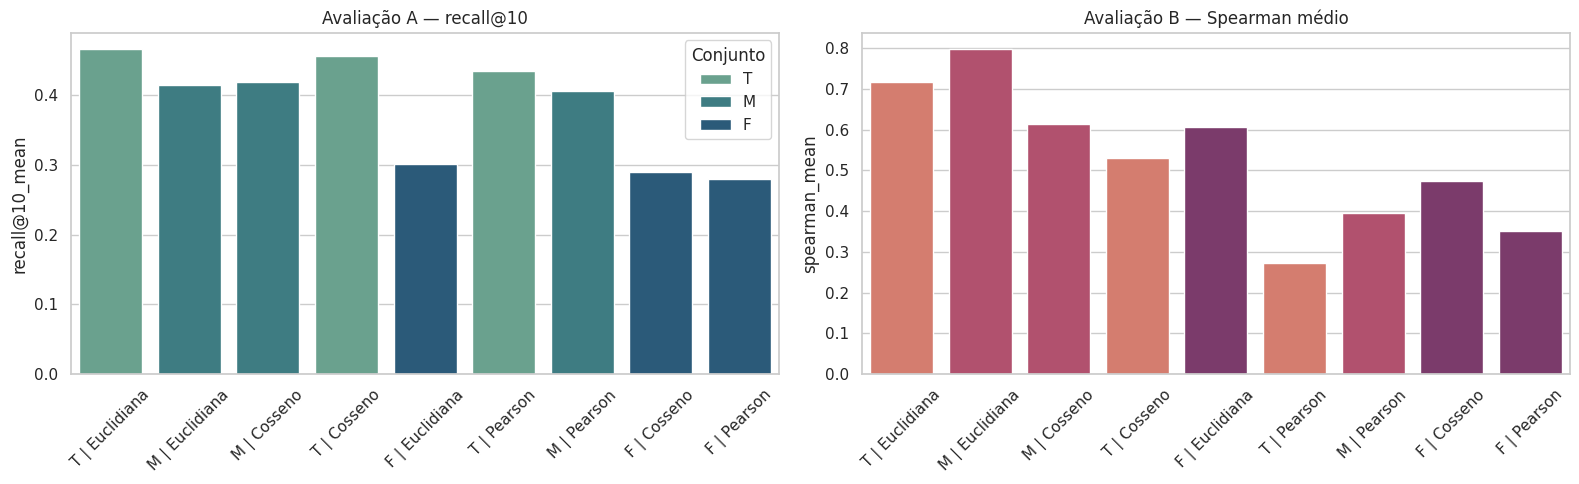

,feature_set,comparison,jaccard@10
6,F,Euclidiana vs Cosseno,0.321203
8,F,Cosseno vs Pearson,0.173478
7,F,Euclidiana vs Pearson,0.100199
3,M,Euclidiana vs Cosseno,0.438297
5,M,Cosseno vs Pearson,0.279680
4,M,Euclidiana vs Pearson,0.192629
0,T,Euclidiana vs Cosseno,0.385754
2,T,Cosseno vs Pearson,0.192070
1,T,Euclidiana vs Pearson,0.126009


,global_sp_mean,specialist_threshold_p90,n_specialist_queries,winner_neighbor_sp_mean,sp_only_neighbor_sp_mean,winner_neighbor_specialist_rate,sp_only_neighbor_specialist_rate
0,0.0,1.050236,7829,0.908432,1.418738,0.406553,0.942304


,query_role,query_uid,neighbor_rank,neighbor_uid,neighbor_role
0,AM,2002078863,1,19399448,AM
1,AM,2002078863,2,2002075081,AM
2,AM,2002078863,3,31042062,MID
3,AM,2002078863,4,2002078072,AM
4,AM,2002078863,5,70109065,MID
5,DEF,2002078813,1,72052927,AM
6,DEF,2002078813,2,2000034619,DEF
7,DEF,2002078813,3,2000163479,DEF
8,DEF,2002078813,4,2000022533,DEF
9,DEF,2002078813,5,93122678,DEF


In [12]:
plot_df = results.copy()
plot_df["label"] = plot_df["condition"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=plot_df, x="label", y="recall@10_mean", hue="feature_set", dodge=False, ax=axes[0], palette="crest")
axes[0].set_title("Avaliação A — recall@10")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Conjunto", loc="best")

sns.barplot(data=plot_df, x="label", y="spearman_mean", hue="feature_set", dodge=False, ax=axes[1], palette="flare")
axes[1].set_title("Avaliação B — Spearman médio")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend_.remove()
plt.tight_layout()
plt.show()

overlap_rows = []
for feature_name in EXPERIMENT_FEATURES:
    for metric_a, metric_b in combinations(METRICS, 2):
        overlap_rows.append({
            "feature_set": FEATURE_ALIASES[feature_name],
            "comparison": f"{METRIC_LABELS[metric_a]} vs {METRIC_LABELS[metric_b]}",
            "jaccard@10": mean_jaccard_at_k(
                neighbors_by_condition[(feature_name, metric_a)],
                neighbors_by_condition[(feature_name, metric_b)],
                top_k=10,
            ),
        })
overlap_df = pd.DataFrame(overlap_rows).sort_values(["feature_set", "jaccard@10"], ascending=[True, False])
display(overlap_df)

winner_experiment = (winner["feature_set_key"], winner["metric_key"])
winner_neighbors = neighbors_by_condition[winner_experiment]

sp_prepared = prepare_metric_space(MATRICES["set_pieces"], winner["metric_key"])
sp_neighbor_blocks = []
for block_start in range(0, len(query_idx), BLOCK_SIZE):
    block_idx = query_idx[block_start:block_start + BLOCK_SIZE]
    sp_scores = score_block(MATRICES["set_pieces"][block_idx], sp_prepared)
    sp_neighbor_blocks.append(topk_from_scores(sp_scores, block_idx, max_k))
sp_neighbors = np.vstack(sp_neighbor_blocks)

sp_strength = df[feature_sets["set_pieces"]].mean(axis=1).to_numpy()
specialist_threshold = float(np.quantile(sp_strength, 0.90))
specialist_queries = sp_strength[query_idx] >= specialist_threshold

winner_neighbor_sp = sp_strength[winner_neighbors[specialist_queries, :10]].mean()
sp_only_neighbor_sp = sp_strength[sp_neighbors[specialist_queries, :10]].mean()
winner_specialist_rate = (sp_strength[winner_neighbors[specialist_queries, :10]] >= specialist_threshold).mean()
sp_only_specialist_rate = (sp_strength[sp_neighbors[specialist_queries, :10]] >= specialist_threshold).mean()

robustness_df = pd.DataFrame([
    {
        "global_sp_mean": float(sp_strength.mean()),
        "specialist_threshold_p90": specialist_threshold,
        "n_specialist_queries": int(specialist_queries.sum()),
        "winner_neighbor_sp_mean": float(winner_neighbor_sp),
        "sp_only_neighbor_sp_mean": float(sp_only_neighbor_sp),
        "winner_neighbor_specialist_rate": float(winner_specialist_rate),
        "sp_only_neighbor_specialist_rate": float(sp_only_specialist_rate),
    }
])
display(robustness_df)

query_position = {row_idx: pos for pos, row_idx in enumerate(query_idx.tolist())}
example_rows = []
for role in role_order:
    example_query = query_df.loc[query_df["primary_role"] == role].iloc[0]
    query_pos = query_position[int(example_query["row_idx"])]
    for rank, neighbor_idx in enumerate(winner_neighbors[query_pos, :5], start=1):
        example_rows.append({
            "query_role": role,
            "query_uid": int(example_query["UID"]),
            "neighbor_rank": rank,
            "neighbor_uid": int(UIDS[neighbor_idx]),
            "neighbor_role": ROLES[neighbor_idx],
        })

examples_df = pd.DataFrame(example_rows)
display(examples_df)

## 5. Leitura dos resultados

Leituras esperadas:
- `overall_rank` resume o compromisso entre a Avaliação A (`recall@10`) e a Avaliação B (`Spearman`).
- `overlap_df` mostra se as três métricas convergem ou divergem dentro de cada conjunto de features.
- `robustness_df` testa se consultas fortes em bola parada continuam recuperando vizinhos fortes em `SP` sob a condição vencedora do experimento principal.

Se você quiser aproximar o experimento completo, o primeiro parâmetro a aumentar é `MAX_QUERIES_PER_ROLE`. Se houver memória suficiente, aumente também `BLOCK_SIZE` para reduzir o tempo total de execução.